In [1]:
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential,load_model
from keras.layers import Conv2D
from keras.layers import MaxPooling2D,AveragePooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout,Input
from keras.optimizers import SGD

In [119]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
cifar10??

Type:        module
String form: <module 'keras.api.datasets.cifar10' from '/opt/anaconda3/lib/python3.12/site-packages/keras/api/datasets/cifar10/__init__.py'>
File:        /opt/anaconda3/lib/python3.12/site-packages/keras/api/datasets/cifar10/__init__.py
Source:     
"""DO NOT EDIT.

This file was autogenerated. Do not edit it by hand,
since your modifications would be overwritten.
"""

from keras.src.datasets.cifar10 import load_data

In [9]:
# cifar10.load_data??

In [11]:
# The classes are:

#     | Label | Description |
#     |:-----:|-------------|
#     |   0   | airplane    |
#     |   1   | automobile  |
#     |   2   | bird        |
#     |   3   | cat         |
#     |   4   | deer        |
#     |   5   | dog         |
#     |   6   | frog        |
#     |   7   | horse       |
#     |   8   | ship        |
#     |   9   | truck       |

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
x_train[0].shape

(32, 32, 3)

In [6]:
x_train[0][0][0]

array([59, 62, 63], dtype=uint8)

In [7]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

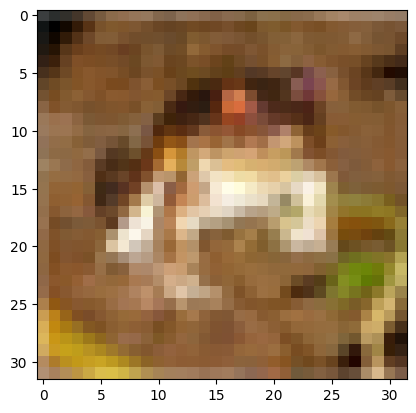

In [8]:
plt.imshow(x_train[0])
plt.show()

In [9]:
y_train[0]

array([6], dtype=uint8)

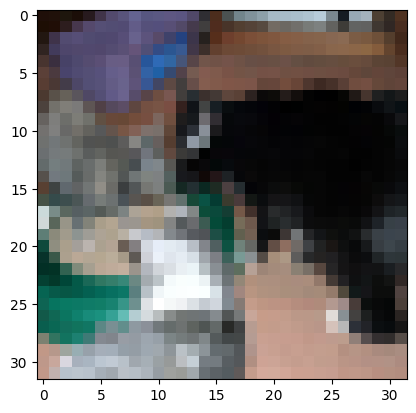

In [10]:
plt.imshow(x_train[12546])
plt.show()

In [11]:
y_train[12546]

array([3], dtype=uint8)

In [12]:
x_train_f = x_train.astype(float)
x_test_f = x_test.astype(float)

In [13]:
x_train_f[0][0][0]

array([59., 62., 63.])

In [14]:
x_train_f.dtype

dtype('float64')

In [15]:
x_train_normalize = x_train_f/255.0
x_test_normalize = x_test_f/255.0

In [16]:
x_train_normalize[0][0][0]

array([0.23137255, 0.24313725, 0.24705882])

In [17]:
to_categorical([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], num_classes=10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [18]:
trainY = to_categorical(y_train)
testY = to_categorical(y_test)

In [19]:
trainY[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [45]:
# Input??
# Conv2D??
MaxPooling2D??

Init signature:
MaxPooling2D(
    pool_size=(2, 2),
    strides=None,
    padding='valid',
    data_format=None,
    name=None,
    **kwargs,
)
Source:        
@keras_export(["keras.layers.MaxPooling2D", "keras.layers.MaxPool2D"])
class MaxPooling2D(BasePooling):
    """Max pooling operation for 2D spatial data.

    Downsamples the input along its spatial dimensions (height and width)
    by taking the maximum value over an input window
    (of size defined by `pool_size`) for each channel of the input.
    The window is shifted by `strides` along each dimension.

    The resulting output when using the `"valid"` padding option has a spatial
    shape (number of rows or columns) of:
    `output_shape = math.floor((input_shape - pool_size) / strides) + 1`
    (when `input_shape >= pool_size`)

    The resulting output shape when using the `"same"` padding option is:
    `output_shape = math.floor((input_shape - 1) / strides) + 1`

    Args:
        pool_size: int or tuple of 2 integers

In [41]:
x_train[0].shape

(32, 32, 3)

In [47]:
model = Sequential()
model.add(Input(shape=x_train[0].shape))
model.add(Conv2D(filters=128,kernel_size=(3,3),activation="relu",padding="same"))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(10,activation="softmax"))

In [55]:
128*9*3 + 128

3584

In [59]:
16*16*128

32768

In [63]:
32768*128 + 128

4194432

In [65]:
128*64 + 64

8256

In [67]:
64*10 + 10

650

In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,206,922 (16.05 MB)

 Trainable params: 4,206,922 (16.05 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model.compile(optimizer="sgd",loss="categorical_crossentropy",metrics=["accuracy"])

In [73]:
history = model.fit(x_train_normalize,trainY,epochs=50,batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2224 - loss: 2.1374
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3788 - loss: 1.7587
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.4431 - loss: 1.5596
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4891 - loss: 1.4313
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.5327 - loss: 1.3257
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5498 - loss: 1.2591
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.5738 - loss: 1.1988
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5947 - loss: 1.1572
Epoch 9/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6061 - loss: 1.1175
Epoch 10/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6235 - loss: 1.0782
Epoch 11/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6332 - loss: 1.0458
Epoch 12/50
782/782 ━━━━━━━━━━

In [79]:
acc = history.history["accuracy"]

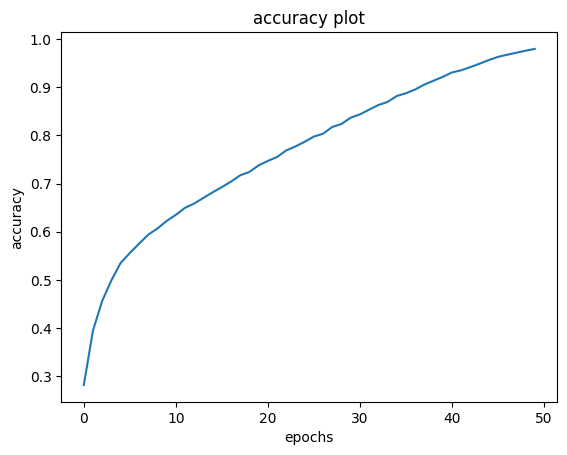

In [83]:
plt.plot(acc)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("accuracy plot")
plt.show()

In [85]:
model.evaluate(x_test_normalize,testY)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6543 - loss: 1.5822


[1.6209417581558228, 0.650600016117096]

In [87]:
model.save("cifar10_classification.keras")

In [93]:
saved_model = load_model("./cifar10_classification.keras")

In [99]:
x_train_normalize.shape

(50000, 32, 32, 3)

In [97]:
x_test_normalize[0].shape

(32, 32, 3)

In [105]:
xin = x_test_normalize[0].reshape(1,32,32,3)

In [109]:
xin.shape

(1, 32, 32, 3)

In [111]:
ypred = model.predict(xin)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [113]:
ypred

array([[3.3546279e-05, 7.8942167e-06, 1.5208618e-06, 9.0844959e-01,
        2.5967043e-07, 9.1140822e-02, 3.5056124e-07, 8.5819975e-06,
        3.5314806e-04, 4.3037876e-06]], dtype=float32)

In [115]:
ypred.sum()

1.0000001

In [121]:
np.argmax(ypred)

3

In [123]:
y_test[0]

array([3], dtype=uint8)

In [125]:
model = Sequential()
model.add(Input(shape=x_train_normalize[0].shape))

model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer="he_uniform"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))


model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(10,activation="softmax"))

In [127]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)